Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


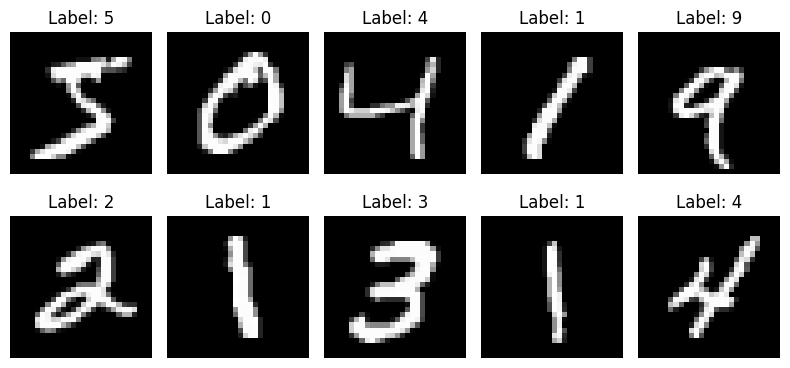


Feature Method: Raw Pixels
Feature vector shape: (8000, 784)
Accuracy: 0.888

Feature Method: Histogram
Feature vector shape: (8000, 32)
Accuracy: 0.3175

Feature Method: Edges
Feature vector shape: (8000, 784)
Accuracy: 0.8295

Feature Method: HOG
Feature vector shape: (8000, 324)
Accuracy: 0.945

Feature Method: LBP
Feature vector shape: (8000, 10)
Accuracy: 0.3935

Feature Method: HOG + LBP
Feature vector shape: (8000, 334)
Accuracy: 0.9485


Final Comparison:
  Feature Method  Feature Vector Size  Accuracy
5      HOG + LBP                  334    0.9485
3            HOG                  324    0.9450
0     Raw Pixels                  784    0.8880
2          Edges                  784    0.8295
4            LBP                   10    0.3935
1      Histogram                   32    0.3175


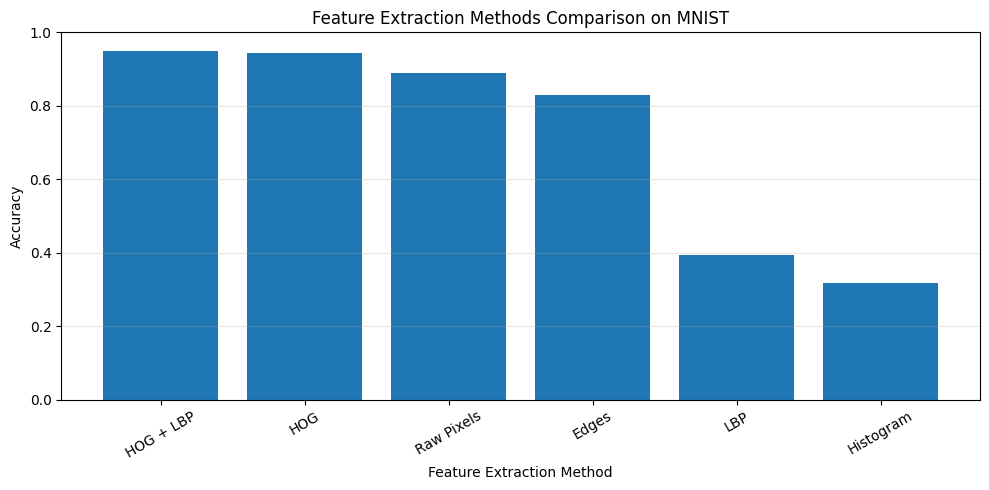


Best Feature Method: HOG + LBP
Best Accuracy: 0.9485

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       175
           1       0.97      0.99      0.98       234
           2       0.95      0.96      0.95       219
           3       0.90      0.91      0.91       207
           4       0.93      0.97      0.95       217
           5       0.95      0.96      0.95       179
           6       0.95      0.97      0.96       178
           7       0.96      0.90      0.93       205
           8       0.95      0.91      0.93       192
           9       0.96      0.93      0.95       194

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000


Confusion Matrix:
[[171   0   0   1   0   0   2   0   1   0]
 [  0 232   0   1   0   1   0   0   0   0]
 [  2   1 210   3   1   0   0   2   0   0]
 [  1   0   2 1

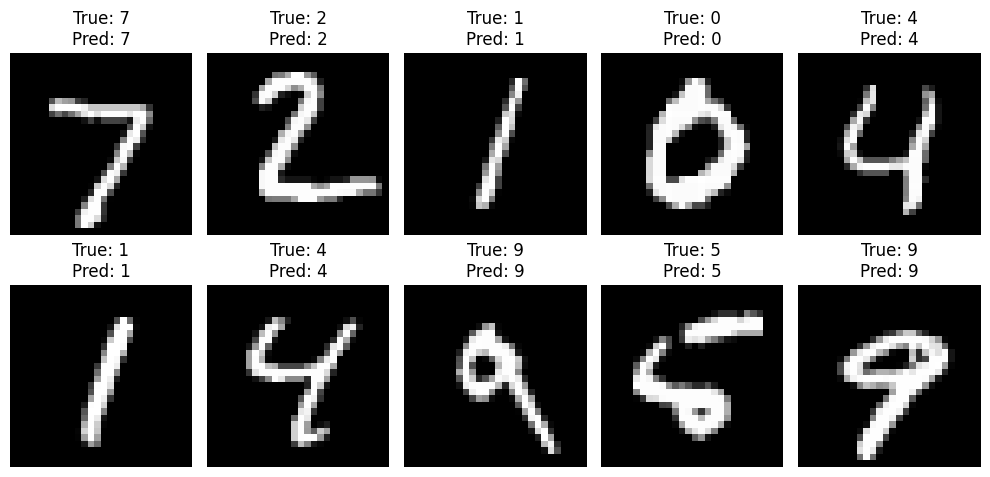

In [13]:
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist

from skimage.feature import hog, local_binary_pattern

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split


# =====================================================
# 1. Load MNIST Dataset
# =====================================================

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)


# =====================================================
# 2. Use small sample for faster training
# =====================================================

train_size = 8000
test_size = 2000

x_train = x_train[:train_size]
y_train = y_train[:train_size]

x_test = x_test[:test_size]
y_test = y_test[:test_size]


# =====================================================
# 3. Show sample images
# =====================================================

plt.figure(figsize=(8, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


# =====================================================
# 4. Feature Extraction Functions
# =====================================================

def extract_raw_pixels(images):
    """
    Convert each image from 28x28 to 784 numbers.
    """
    features = images.reshape(len(images), -1)
    features = features / 255.0
    return features


def extract_histogram(images, bins=32):
    """
    Extract grayscale histogram from each image.
    """
    features = []

    for img in images:
        hist = cv2.calcHist(
            [img.astype(np.uint8)],
            [0],
            None,
            [bins],
            [0, 256]
        )

        hist = hist.flatten()

        # Normalize histogram
        hist = hist / (hist.sum() + 1e-7)

        features.append(hist)

    return np.array(features)


def extract_edges(images):
    """
    Extract Canny edges then flatten.
    """
    features = []

    for img in images:
        img_uint8 = img.astype(np.uint8)

        edges = cv2.Canny(img_uint8, 50, 150)

        edge_vector = edges.flatten() / 255.0

        features.append(edge_vector)

    return np.array(features)


def extract_hog(images):
    """
    Extract HOG features.
    HOG describes edge directions and shape.
    """
    features = []

    for img in images:
        img_norm = img / 255.0

        hog_feature = hog(
            img_norm,
            orientations=9,
            pixels_per_cell=(7, 7),
            cells_per_block=(2, 2),
            block_norm="L2-Hys"
        )

        features.append(hog_feature)

    return np.array(features)


def extract_lbp(images, radius=1, points=8):
    """
    Extract LBP texture features.
    We convert LBP image to histogram.
    """
    features = []

    for img in images:
        lbp = local_binary_pattern(
            img,
            P=points,
            R=radius,
            method="uniform"
        )

        n_bins = points + 2

        hist, _ = np.histogram(
            lbp.ravel(),
            bins=n_bins,
            range=(0, n_bins)
        )

        hist = hist.astype("float")
        hist = hist / (hist.sum() + 1e-7)

        features.append(hist)

    return np.array(features)


def extract_hog_lbp(images):
    """
    Combine HOG and LBP features.
    """
    hog_features = extract_hog(images)
    lbp_features = extract_lbp(images)

    combined = np.hstack([hog_features, lbp_features])

    return combined


# =====================================================
# 5. Prepare all feature sets
# =====================================================

feature_methods = {
    "Raw Pixels": extract_raw_pixels,
    "Histogram": extract_histogram,
    "Edges": extract_edges,
    "HOG": extract_hog,
    "LBP": extract_lbp,
    "HOG + LBP": extract_hog_lbp
}


# =====================================================
# 6. Train and evaluate SVM for each feature type
# =====================================================

results = []

best_model = None
best_accuracy = 0
best_method_name = ""

for method_name, extractor in feature_methods.items():

    print("\n" + "=" * 60)
    print(f"Feature Method: {method_name}")
    print("=" * 60)

    # Extract features
    X_train_features = extractor(x_train)
    X_test_features = extractor(x_test)

    print("Feature vector shape:", X_train_features.shape)

    # Create ML model
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="linear"))
    ])

    # Train
    model.fit(X_train_features, y_train)

    # Predict
    y_pred = model.predict(X_test_features)

    # Evaluate
    acc = accuracy_score(y_test, y_pred)

    print("Accuracy:", acc)

    results.append({
        "Feature Method": method_name,
        "Feature Vector Size": X_train_features.shape[1],
        "Accuracy": acc
    })

    if acc > best_accuracy:
        best_accuracy = acc
        best_model = model
        best_method_name = method_name
        best_X_test = X_test_features
        best_y_pred = y_pred


# =====================================================
# 7. Show comparison table
# =====================================================

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print("\n\nFinal Comparison:")
print(results_df)


# =====================================================
# 8. Plot accuracy comparison
# =====================================================

plt.figure(figsize=(10, 5))
plt.bar(results_df["Feature Method"], results_df["Accuracy"])
plt.title("Feature Extraction Methods Comparison on MNIST")
plt.xlabel("Feature Extraction Method")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# =====================================================
# 9. Print detailed report for best method
# =====================================================

print("\nBest Feature Method:", best_method_name)
print("Best Accuracy:", best_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, best_y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, best_y_pred))


# =====================================================
# 10. Show predictions using best model
# =====================================================

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i], cmap="gray")

    true_label = y_test[i]
    pred_label = best_y_pred[i]

    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()